# Caption `Trey_01.png` with a VLM via Alloy

This notebook sends the image `Trey_01.png` through a vision-language model using the Alloy client's `image()` function, and clearly shows both the **prompt** used and the **model output**.

## 1. Setup

Import the Alloy vision helper. If the `alloy` package isn't installed in this environment, install it from the local wheel first (uncomment the `%pip` line).

In [1]:
# %pip install alloy_sandbox_client-2.0.1a1-py3-none-any.whl

from alloy.core.llm.core import image
from pathlib import Path
from IPython.display import Image, Markdown, display

## 2. Preview the image

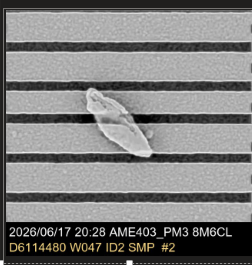

In [2]:
IMAGE_PATH = "Trey_01.png"
assert Path(IMAGE_PATH).is_file(), f"Image not found: {IMAGE_PATH}"

display(Image(filename=IMAGE_PATH, width=500))

## 3. Define the captioning prompt

This is the exact instruction sent to the VLM.

In [6]:
CAPTION_PROMPT = (
    "You are an expert SEM image captioner. Your job is to caption images effectively so they can be binned into different categories. Focus on capturing details such as "
    "different morphologies, size, location of the potential particles in the images. If there are no particles present, mention that explicitly."
)

print("PROMPT SENT TO VLM:\n")
print(CAPTION_PROMPT)

PROMPT SENT TO VLM:

You are an expert SEM image captioner. Your job is to caption images effectively so they can be binned into different categories. Focus on capturing details such as different morphologies, size, location of the potential particles in the images. If there are no particles present, mention that explicitly.


## 4. Send the image through the VLM

`image()` accepts a file path, converts it to base64, and calls the Alloy vision endpoint. The model defaults to the configured vision model (`ALLOY_MODEL_VISION`).

In [12]:
caption = image(
    IMAGE_PATH,
    prompt=CAPTION_PROMPT,
    model="gpt-5.4",
    max_completion_tokens=500,
)

caption

'Single elongated, platelet-like particle centered slightly left of the image, oriented diagonally from upper-left to lower-right and bridging across multiple horizontal substrate lines. The particle has a tapered, leaf-like shape with uneven thickness and a small protruding fragment on its upper-left end. Size appears moderate relative to the line spacing, spanning roughly 2–3 stripe gaps. No other distinct particles are visible; background consists of parallel horizontal bands.'

## 5. Show the result

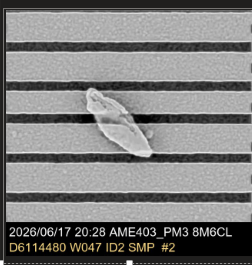

**Image:** `Trey_01.png`

**Caption:**

> Single elongated, platelet-like particle centered slightly left of the image, oriented diagonally from upper-left to lower-right and bridging across multiple horizontal substrate lines. The particle has a tapered, leaf-like shape with uneven thickness and a small protruding fragment on its upper-left end. Size appears moderate relative to the line spacing, spanning roughly 2–3 stripe gaps. No other distinct particles are visible; background consists of parallel horizontal bands.

In [13]:
display(Image(filename=IMAGE_PATH, width=500))
display(Markdown(f"**Image:** `{IMAGE_PATH}`\n\n**Caption:**\n\n> {caption}"))